In [12]:
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

In [13]:
TIEMPO_ESTIMADO_MIN = 2

In [14]:
lineas = {
    "1": [
        "Observatorio",
        "Tacubaya",
        "Juanacatlán",
        "Chapultepec",
        "Sevilla",
        "Insurgentes",
        "Cuauhtémoc",
        "Balderas",
        "Salto del Agua",
        "Isabel la Católica",
        "Pino Suárez",
        "Merced",
        "Candelaria",
        "San Lázaro",
        "Moctezuma",
        "Balbuena",
        "Boulevard Puerto Aéreo",
        "Gómez Farías",
        "Zaragoza",
        "Pantitlán"
    ],

    "2": [
        "Cuatro Caminos",
        "Panteones",
        "Tacuba",
        "Cuitláhuac",
        "Popotla",
        "Colegio Militar",
        "Normal",
        "San Cosme",
        "Revolución",
        "Hidalgo",
        "Bellas Artes",
        "Allende",
        "Zócalo/Tenochtitlan",
        "Pino Suárez",
        "San Antonio Abad",
        "Chabacano",
        "Viaducto",
        "Xola",
        "Villa de Cortés",
        "Nativitas",
        "Portales",
        "Ermita",
        "General Anaya",
        "Tasqueña"
    ],

    "3": [
        "Indios Verdes",
        "Deportivo 18 de Marzo",
        "Potrero",
        "La Raza",
        "Tlatelolco",
        "Guerrero",
        "Hidalgo",
        "Juárez",
        "Balderas",
        "Niños Héroes",
        "Hospital General",
        "Centro Médico",
        "Etiopía/Plaza de la Transparencia",
        "Eugenia",
        "División del Norte",
        "Zapata",
        "Coyoacán",
        "Viveros/Derechos Humanos",
        "Miguel Ángel de Quevedo",
        "Copilco",
        "Universidad"
    ],

    "4": [
        "Martín Carrera",
        "Talismán",
        "Bondojito",
        "Consulado",
        "Canal del Norte",
        "Morelos",
        "Candelaria",
        "Fray Servando",
        "Jamaica",
        "Santa Anita"
    ],

    "5": [
        "Politécnico",
        "Instituto del Petróleo",
        "Autobuses del Norte",
        "La Raza",
        "Misterios",
        "Valle Gómez",
        "Consulado",
        "Eduardo Molina",
        "Aragón",
        "Oceanía",
        "Terminal Aérea",
        "Hangares",
        "Pantitlán"
    ],

    "6": [
        "El Rosario",
        "Tezozómoc",
        "Azcapotzalco",
        "Ferrería/Arena Ciudad de México",
        "Norte 45",
        "Vallejo",
        "Instituto del Petróleo",
        "Lindavista",
        "Deportivo 18 de Marzo",
        "La Villa-Basílica",
        "Martín Carrera"
    ],

    "7": [
        "El Rosario",
        "Aquiles Serdán",
        "Camarones",
        "Refinería",
        "Tacuba",
        "San Joaquín",
        "Polanco",
        "Auditorio",
        "Constituyentes",
        "Tacubaya",
        "San Pedro de los Pinos",
        "San Antonio",
        "Mixcoac",
        "Barranca del Muerto"
    ],

    "8": [
        "Garibaldi/Lagunilla",
        "Bellas Artes",
        "San Juan de Letrán",
        "Salto del Agua",
        "Doctores",
        "Obrera",
        "Chabacano",
        "La Viga",
        "Santa Anita",
        "Coyuya",
        "Iztacalco",
        "Apatlaco",
        "Aculco",
        "Escuadrón 201",
        "Atlalilco",
        "Iztapalapa",
        "Cerro de la Estrella",
        "UAM-I",
        "Constitución de 1917"
    ],

    "9": [
        "Tacubaya",
        "Patriotismo",
        "Chilpancingo",
        "Centro Médico",
        "Lázaro Cárdenas",
        "Chabacano",
        "Jamaica",
        "Mixiuhca",
        "Velódromo",
        "Ciudad Deportiva",
        "Puebla",
        "Pantitlán"
    ],

    "A": [
        "Pantitlán",
        "Agrícola Oriental",
        "Canal de San Juan",
        "Tepalcates",
        "Guelatao",
        "Peñón Viejo",
        "Acatitla",
        "Santa Marta",
        "Los Reyes",
        "La Paz"
    ],

    "B": [
        "Ciudad Azteca",
        "Plaza Aragón",
        "Olímpica",
        "Ecatepec",
        "Múzquiz",
        "Río de los Remedios",
        "Impulsora",
        "Nezahualcóyotl",
        "Villa de Aragón",
        "Bosque de Aragón",
        "Deportivo Oceanía",
        "Oceanía",
        "Romero Rubio",
        "Ricardo Flores Magón",
        "San Lázaro",
        "Morelos",
        "Tepito",
        "Lagunilla",
        "Garibaldi/Lagunilla",
        "Guerrero",
        "Buenavista"
    ],

    "12": [
        "Mixcoac",
        "Insurgentes Sur",
        "Hospital 20 de Noviembre",
        "Zapata",
        "Parque de los Venados",
        "Eje Central",
        "Ermita",
        "Mexicaltzingo",
        "Atlalilco",
        "Culhuacán",
        "San Andrés Tomatlán",
        "Lomas Estrella",
        "Calle 11",
        "Periférico Oriente",
        "Tezonco",
        "Olivos",
        "Nopalera",
        "Zapotitlán",
        "Tlaltenco",
        "Tláhuac"
    ]
}

In [15]:
def construir_grafo(lineas: dict, tiempo: int = TIEMPO_ESTIMADO_MIN) -> dict:
    metro_cdmx = {}

    for estaciones in lineas.values():
        for i in range(len(estaciones) - 1):
            a = estaciones[i]
            b = estaciones[i + 1]

            metro_cdmx.setdefault(a, {})[b] = tiempo
            metro_cdmx.setdefault(b, {})[a] = tiempo

    return metro_cdmx


metro_cdmx = construir_grafo(lineas)

print(f"Total de estaciones (nodos): {len(metro_cdmx)}")
print(f"Vecinos de Pantitlán: {metro_cdmx['Pantitlán']}")

Total de estaciones (nodos): 163
Vecinos de Pantitlán: {'Zaragoza': 2, 'Hangares': 2, 'Puebla': 2, 'Agrícola Oriental': 2}


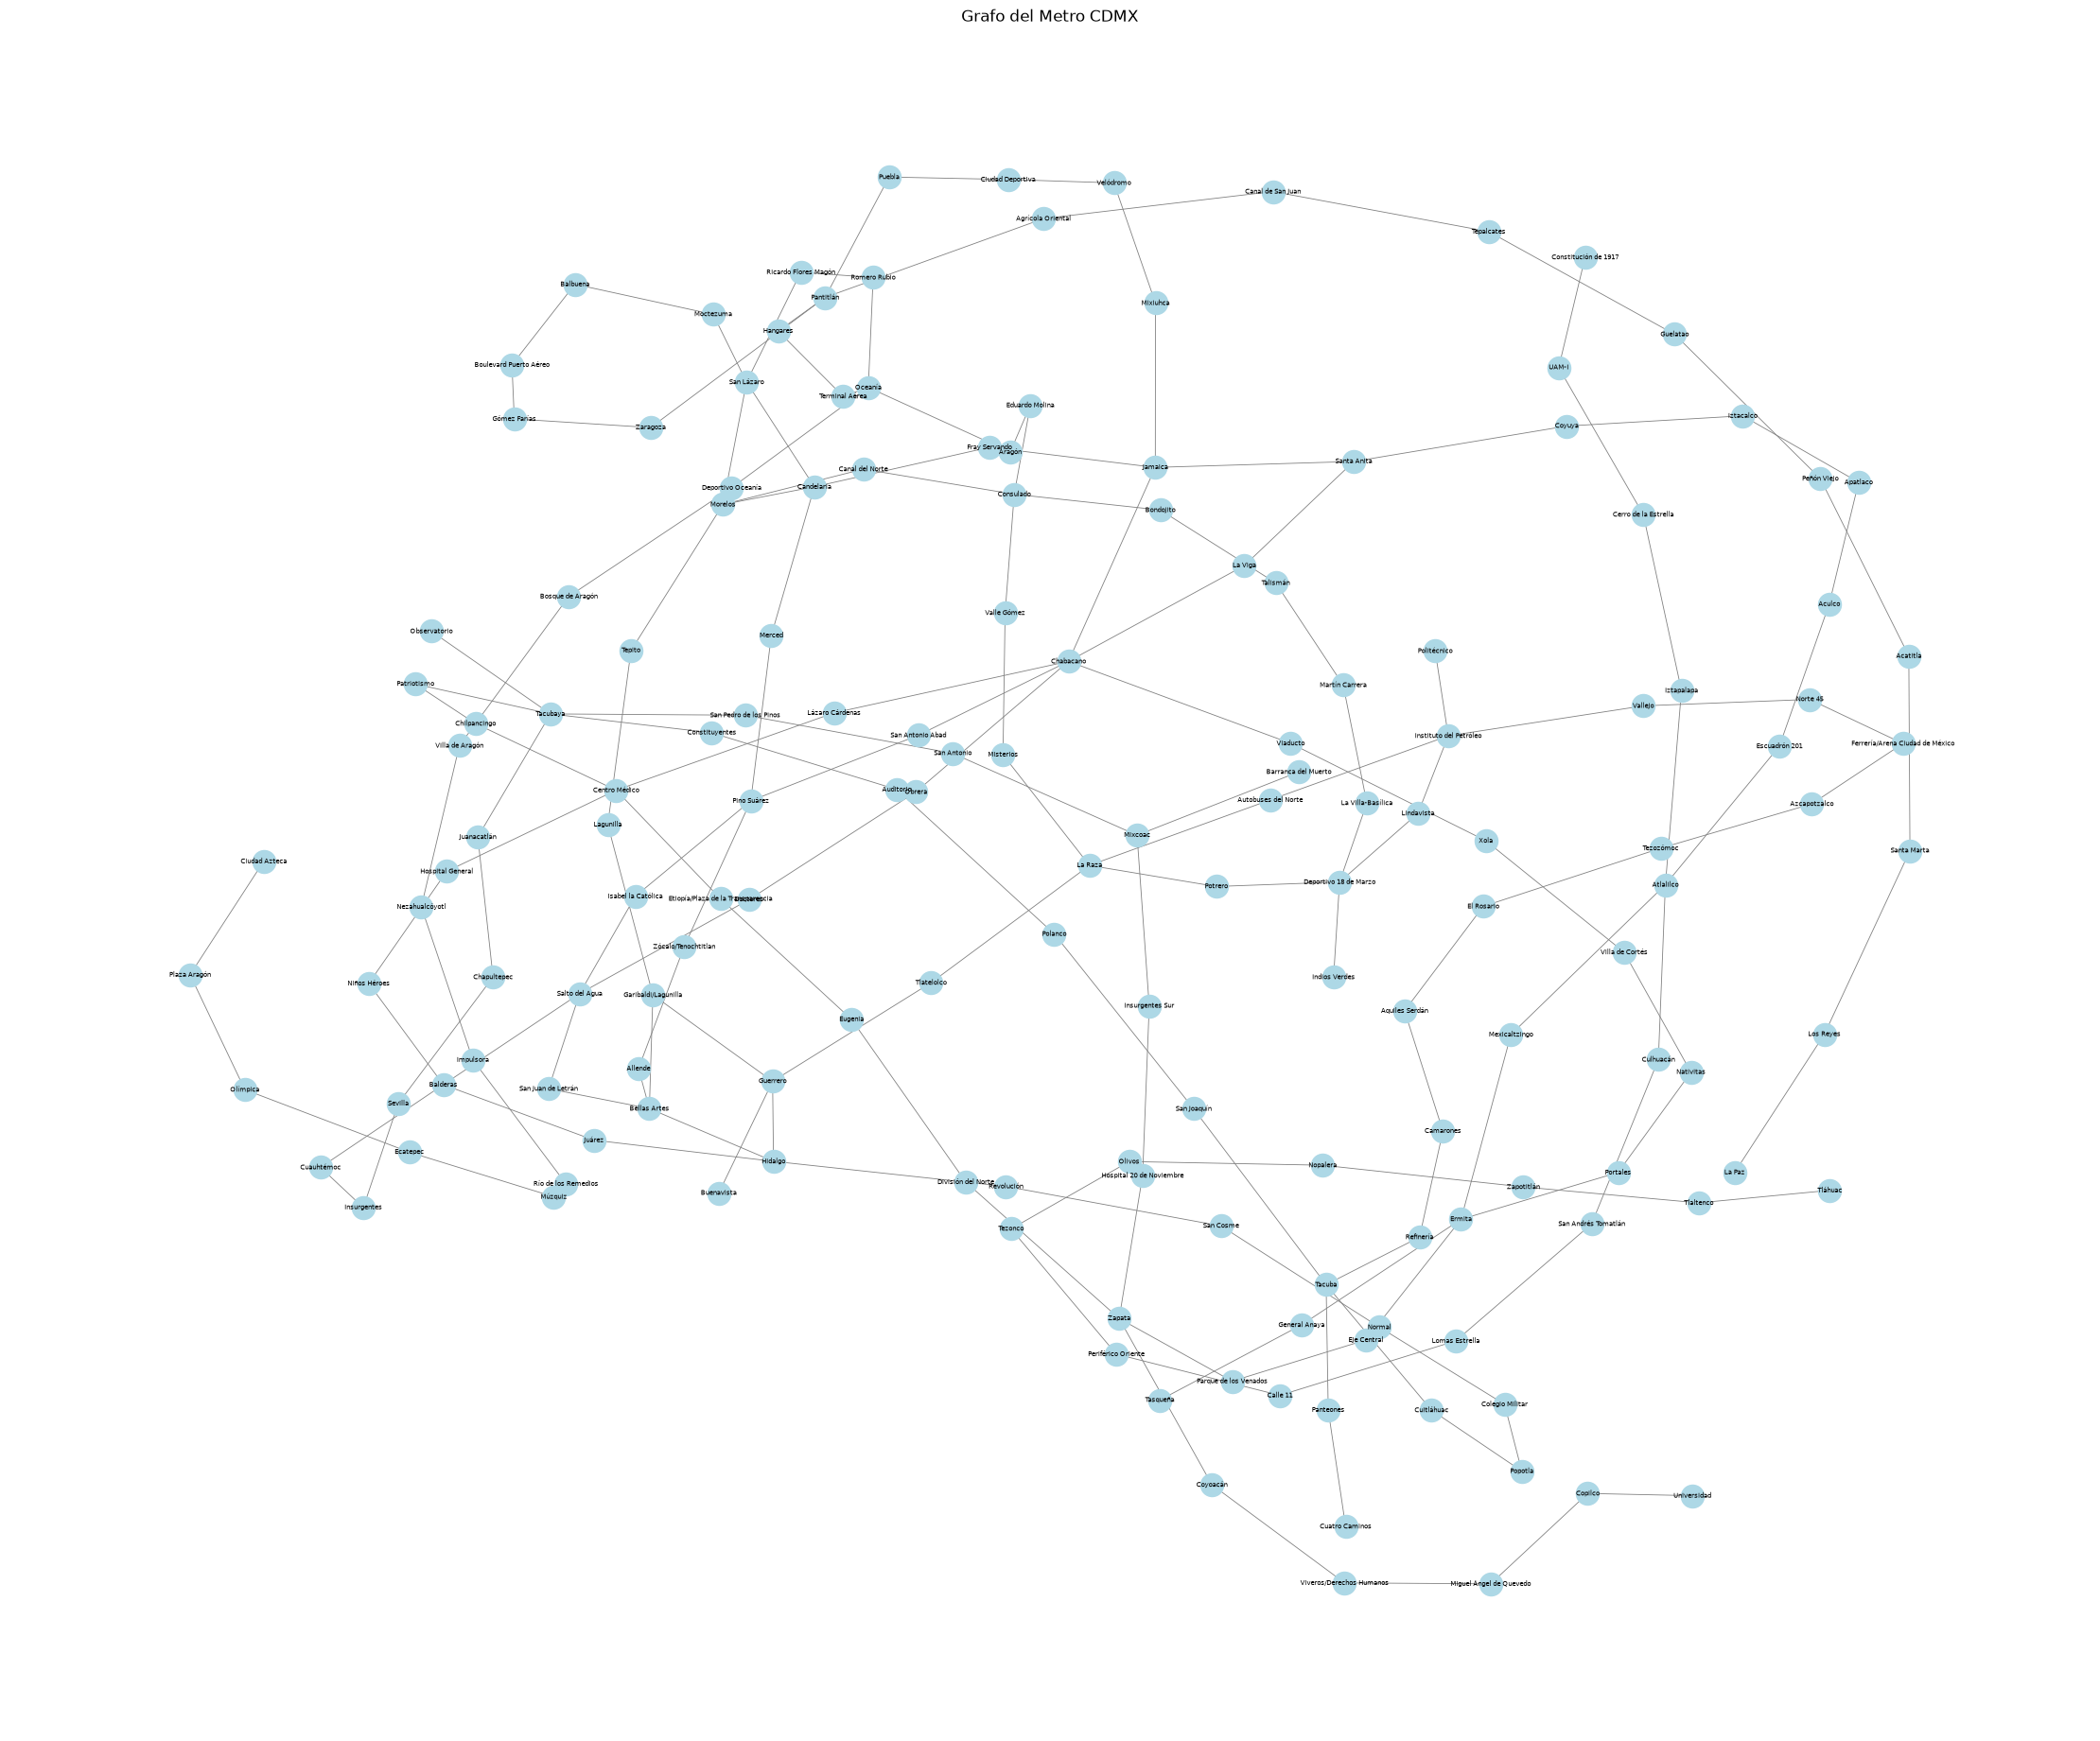

In [16]:
def dibujar_grafo(metro_cdmx: dict):
    G = nx.Graph()

    for nodo, vecinos in metro_cdmx.items():
        for vecino, peso in vecinos.items():
            G.add_edge(nodo, vecino, weight=peso)

    plt.figure(figsize=(22, 18))

    pos = nx.spring_layout(
        G,
        seed=42,
        k=0.35,
        iterations=100
    )

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=300,
        font_size=5,
        edge_color="gray",
        width=0.6
    )

    plt.title("Grafo del Metro CDMX")
    plt.axis("off")
    plt.show()


dibujar_grafo(metro_cdmx)

In [17]:
def bfs(grafo: dict, inicio: str, destino: str):
    cola = deque([[inicio]])
    visitados = {inicio}

    while cola:
        ruta = cola.popleft()
        actual = ruta[-1]

        if actual == destino:
            return ruta

        for vecino in grafo[actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                nueva_ruta = ruta + [vecino]
                cola.append(nueva_ruta)

    return None

In [18]:
ruta = bfs(
    metro_cdmx,
    "Cuatro Caminos",
    "Pantitlán"
)

if ruta:
    costo = (len(ruta) - 1) * TIEMPO_ESTIMADO_MIN

    print("BFS: Cuatro Caminos -> Pantitlán")
    print(" -> ".join(ruta))
    print(f"Costo estimado: {costo} minutos")
else:
    print("No se encontró una ruta.")

BFS: Cuatro Caminos -> Pantitlán
Cuatro Caminos -> Panteones -> Tacuba -> San Joaquín -> Polanco -> Auditorio -> Constituyentes -> Tacubaya -> Patriotismo -> Chilpancingo -> Centro Médico -> Lázaro Cárdenas -> Chabacano -> Jamaica -> Mixiuhca -> Velódromo -> Ciudad Deportiva -> Puebla -> Pantitlán
Costo estimado: 36 minutos


In [19]:
rutas_prueba = [
    ("Cuatro Caminos", "Pantitlán"),
    ("Politécnico", "Tasqueña"),
    ("Zapata", "Oceanía")
]

for inicio, destino in rutas_prueba:

    ruta = bfs(
        metro_cdmx,
        inicio,
        destino
    )

    if ruta:
        costo = (len(ruta) - 1) * TIEMPO_ESTIMADO_MIN

        print(f"\nBFS: {inicio} -> {destino}")
        print(" -> ".join(ruta))
        print(f"Movimientos: {len(ruta) - 1}")
        print(f"Costo estimado: {costo} minutos")


BFS: Cuatro Caminos -> Pantitlán
Cuatro Caminos -> Panteones -> Tacuba -> San Joaquín -> Polanco -> Auditorio -> Constituyentes -> Tacubaya -> Patriotismo -> Chilpancingo -> Centro Médico -> Lázaro Cárdenas -> Chabacano -> Jamaica -> Mixiuhca -> Velódromo -> Ciudad Deportiva -> Puebla -> Pantitlán
Movimientos: 18
Costo estimado: 36 minutos

BFS: Politécnico -> Tasqueña
Politécnico -> Instituto del Petróleo -> Autobuses del Norte -> La Raza -> Tlatelolco -> Guerrero -> Hidalgo -> Bellas Artes -> Allende -> Zócalo/Tenochtitlan -> Pino Suárez -> San Antonio Abad -> Chabacano -> Viaducto -> Xola -> Villa de Cortés -> Nativitas -> Portales -> Ermita -> General Anaya -> Tasqueña
Movimientos: 20
Costo estimado: 40 minutos

BFS: Zapata -> Oceanía
Zapata -> División del Norte -> Eugenia -> Etiopía/Plaza de la Transparencia -> Centro Médico -> Lázaro Cárdenas -> Chabacano -> Jamaica -> Fray Servando -> Candelaria -> San Lázaro -> Ricardo Flores Magón -> Romero Rubio -> Oceanía
Movimientos: 13
C

In [20]:
def dfs(grafo: dict, inicio: str, destino: str):
    pila = [[inicio]]
    visitados = set()

    while pila:
        ruta = pila.pop()
        actual = ruta[-1]

        if actual == destino:
            return ruta

        if actual not in visitados:
            visitados.add(actual)

            for vecino in grafo[actual]:
                if vecino not in visitados:
                    nueva_ruta = ruta + [vecino]
                    pila.append(nueva_ruta)

    return None

In [21]:
for inicio, destino in rutas_prueba:

    ruta = dfs(
        metro_cdmx,
        inicio,
        destino
    )

    if ruta:
        costo = (len(ruta) - 1) * TIEMPO_ESTIMADO_MIN

        print(f"\nDFS: {inicio} -> {destino}")
        print(" -> ".join(ruta))
        print(f"Movimientos: {len(ruta) - 1}")
        print(f"Costo estimado: {costo} minutos")


DFS: Cuatro Caminos -> Pantitlán
Cuatro Caminos -> Panteones -> Tacuba -> San Joaquín -> Polanco -> Auditorio -> Constituyentes -> Tacubaya -> Patriotismo -> Chilpancingo -> Centro Médico -> Lázaro Cárdenas -> Chabacano -> Jamaica -> Mixiuhca -> Velódromo -> Ciudad Deportiva -> Puebla -> Pantitlán
Movimientos: 18
Costo estimado: 36 minutos

DFS: Politécnico -> Tasqueña
Politécnico -> Instituto del Petróleo -> Lindavista -> Deportivo 18 de Marzo -> La Villa-Basílica -> Martín Carrera -> Talismán -> Bondojito -> Consulado -> Eduardo Molina -> Aragón -> Oceanía -> Romero Rubio -> Ricardo Flores Magón -> San Lázaro -> Morelos -> Tepito -> Lagunilla -> Garibaldi/Lagunilla -> Guerrero -> Hidalgo -> Juárez -> Balderas -> Niños Héroes -> Hospital General -> Centro Médico -> Lázaro Cárdenas -> Chabacano -> Jamaica -> Santa Anita -> Coyuya -> Iztacalco -> Apatlaco -> Aculco -> Escuadrón 201 -> Atlalilco -> Mexicaltzingo -> Ermita -> General Anaya -> Tasqueña
Movimientos: 39
Costo estimado: 78 m

In [22]:
for inicio, destino in rutas_prueba:

    ruta_bfs = bfs(
        metro_cdmx,
        inicio,
        destino
    )

    ruta_dfs = dfs(
        metro_cdmx,
        inicio,
        destino
    )

    costo_bfs = (len(ruta_bfs) - 1) * TIEMPO_ESTIMADO_MIN
    costo_dfs = (len(ruta_dfs) - 1) * TIEMPO_ESTIMADO_MIN

    print(f"\nRuta: {inicio} -> {destino}")

    print(
        f"BFS: {len(ruta_bfs) - 1} movimientos, "
        f"{costo_bfs} minutos"
    )

    print(
        f"DFS: {len(ruta_dfs) - 1} movimientos, "
        f"{costo_dfs} minutos"
    )


Ruta: Cuatro Caminos -> Pantitlán
BFS: 18 movimientos, 36 minutos
DFS: 18 movimientos, 36 minutos

Ruta: Politécnico -> Tasqueña
BFS: 20 movimientos, 40 minutos
DFS: 39 movimientos, 78 minutos

Ruta: Zapata -> Oceanía
BFS: 13 movimientos, 26 minutos
DFS: 22 movimientos, 44 minutos
